In [102]:
import numpy as np
from scipy import stats
import random
import csv
import os
from music21 import pitch as pt, note as no, stream, duration as du, converter, tempo, key, converter

In [103]:
CONST = 1e-12

In [104]:
def print_pop(population):
    
    for i in population:
        print(i)

In [105]:
def pairwise_dist(x, y):

        np.random.seed(1)

        """
        Args:
                x: N x D numpy array
                y: M x D numpy array
        Return:
                dist: N x M array, where dist2[i, j] is the euclidean distance between x[i, :] and y[j, :]
        """  

        dist = np.sqrt(np.sum(y**2, axis=1)[np.newaxis, :] + np.sum(x**2, axis=1)[:, np.newaxis] - 2*np.matmul(x, y.T) + CONST)        
        return dist

In [106]:
def cosine_similarity(x, y):

    np.random.seed(1)
    
    """
    Calculates the cosine similarity between two numpy arrays x and y.
    
    Args:
        x: N x D numpy array
        y: M x D numpy array
    
    Returns:
        cos: cosine similarity matrix of size N x M
    """

    cos = np.dot(x, y.T) / (np.dot(np.linalg.norm(x, axis=1, keepdims=True), np.linalg.norm(y, axis=1, keepdims=True).T)  + CONST)
    return cos

In [107]:
def get_avg(input):
    
    np.random.seed(1)
    
    """
        Arg: 
            input: human input numpy array
        Returns:
            mean_pitch: mean value of the first colume
            mean_dur: mean value of the second colume
    """ 
    
    mean_pitch = round(np.mean(input[:, 0]))
    mean_dur = np.mean(input[:, 1])

    return mean_pitch, mean_dur

In [108]:
def reshape_arr(arr1, arr2):
    
    arr1 = np.ravel(arr1)
    arr2 = np.ravel(arr2)

    # Pad zeros to arr2 if it is shorter than arr1
    if len(arr2) < len(arr1):
        arr2 = np.pad(arr2, (0, len(arr1) - len(arr2)), mode='constant')

    # Truncate arr2 if it is longer than arr1
    if len(arr2) > len(arr1):
        arr2 = arr2[:len(arr1)]
        
    arr2 = arr2.reshape(-1,1)

    return arr2

In [109]:
def read_csv(filename):

    """
        Arg: 
            filename: path of the file
        Return:
            data: list
    """ 

    with open(filename, 'r') as f:
        reader = csv.reader(f)
        next(reader) # skip the header row
        data = np.zeros((0,2))
        
        for row in reader:
            data = np.vstack((data, [float(row[1]), float(row[2])]))
            data = data.tolist()
       
    return data

In [110]:
def get_population(dir):
    
    """
        Arg: 
            dir : path of the population csv files
        Return:
            population: list
    """ 

    files = []
    for file in os.listdir(dir):
        if file.endswith('.csv'):
            files.append(os.path.join(dir, file))
    
    population = []
    for file in files:
        data = read_csv(file)
        population.append(data)
    
    return population

In [111]:
def linear_normalize(input):

    """
    Normalize a matrix to [0, 1].
        Arg:
            input: a NumPy array of shape (m, n), where m is the number of rows and n is the number of columns
        Return:
            normalized_arr: a NumPy array of shape (m, n), where each column has zero mean and unit variance
    """
    
    inpt_max = np.max(input, axis=0)
    inpt_min = np.min(input, axis=0)
    
    normalized_arr = (input - inpt_min) / (inpt_max - inpt_min + CONST)
    #print(normalized_arr)

    return(normalized_arr)

In [112]:
def stat_zscore(input):

    """
    Normalize a matrix using Z-score normalization, and handle columns with zero standard deviation.
        Arg:
            input: a NumPy array of shape (m, n), where m is the number of rows and n is the number of columns
        Return:
            zscore_matrix: a NumPy array of shape (m, n), where each column has zero mean and unit variance
    """
    
    zscore_matrix = stats.zscore(input)
    zscore_matrix = np.nan_to_num(zscore_matrix, nan=0)

    return zscore_matrix

In [113]:
def zscore_normalize(input):
    
    """
    Normalize a matrix using Z-score normalization, and handle columns with zero standard deviation.
        Arg:
            input: a NumPy array of shape (m, n), where m is the number of rows and n is the number of columns
        Return:
            normalized_matrix: a NumPy array of shape (m, n), where each column has zero mean and unit variance
    """
    
    # Calculate the mean and standard deviation of each column
    col_means = np.mean(input, axis=0)
    col_stds = np.std(input, axis=0)
    print(col_stds)
    
    # Find the columns with standard deviation 0
    zero_std_cols = np.where(col_stds == 0)[0]
    
    # Add a small constant to the values in the zero std columns
    input = input.astype(np.float64)
    input[:, zero_std_cols] += CONST
    
    # Apply the Z-score normalization formula
    normalized_matrix = (input - col_means) / col_stds
    
    return normalized_matrix

In [141]:
def fitness_dist(input: np.ndarray, population, survial_rate):

    """
        Args: 
            input : N x 2 numpy array
            population: list
            survival_rate: percentage of the population remain
        Return:
            survival population list
    """ 

    if not isinstance(input, np.ndarray):
        raise TypeError("Input must be a numpy array")

    if input.shape[1] != 2:
        raise TypeError("input should be N x 2")
    
    #input = normalized_array(input)
    #input = stat_zscore(input)
    
    scores = [] 
    new_pop = []

    for i in range(0, len(population)):
        
        curr_pop = np.array(population[i]).reshape(len(population[i]),2)
        #curr_pop = normalized_array(curr_pop)
        #curr_pop = stat_zscore(curr_pop)
        dist = pairwise_dist(input, curr_pop)
        scores.append(np.mean(np.diag(dist)))
    
    sorted_indices = np.argsort(scores)
    idx = sorted_indices[:int(len(population) * survial_rate)+1].tolist()
    
    print(idx)
    print(len(idx))
    
    for i in idx:
        new_pop.append(population[i])
    
    population = new_pop
    return population

In [181]:
def fitness(input: np.ndarray, population, survial_rate):

    """
        Args: 
            input : N x 2 numpy array
            population: list
            survival_rate: percentage of the population remain
        Return:
            survival population list
    """ 

    if input.shape[1] != 2:
        raise TypeError("input should be N x 2")

    input_pitch, input_dur = np.split(input, 2, axis=1)
    scores = []
    new_pop = []
    dist_pitch = []
    dist_dur = []

    for i in range(0, len(population)):
        
        curr_pop = np.array(population[i]).reshape(len(population[i]),2)
        curr_pop_pitch, curr_pop_dur = np.split(curr_pop, 2, axis=1)
        curr_pop_pitch = reshape_arr(input_pitch, curr_pop_pitch)
        
        curr_pop_dur = reshape_arr(input_dur, curr_pop_dur)
        dist_p = pairwise_dist(input_pitch, curr_pop_pitch)
        dist_p = np.mean(np.diag(dist_p))
        dist_pitch.append(dist_p)

        dist_d = pairwise_dist(input_dur, curr_pop_dur)
        dist_d = np.mean(np.diag(dist_d))
        dist_dur.append(dist_d)

    distpitch = np.array(dist_pitch)
    distpitch = linear_normalize(distpitch)
    distdur = np.array(dist_dur) 
    distdur = linear_normalize(dist_dur)
    scores = 0.7 * distpitch + 0.3 * distdur
    sorted_indices = np.argsort(scores)
    idx = sorted_indices[:int(len(population) * survial_rate)+1].tolist()
    
    for i in idx:
        new_pop.append(population[i])
    
    population = new_pop
    return population

In [139]:
def fitness_cos(input, population, survial_rate):

    """
        Args: 
            input : N x 2 numpy array
            population: list
            survivak_rate: percentage of the population remain
        Return:
            survival population list
    """ 

    if not isinstance(input, np.ndarray):
        raise TypeError("Input must be a numpy array")

    if input.shape[1] != 2:
        raise TypeError("input should be N x 2")
    
    #input = normalized_array(input)
    input = stat_zscore(input)
    
    scores = [] 
    new_pop = []

    for i in range(0, len(population)):
        
        curr_pop = np.array(population[i]).reshape(len(population[i]),2)
        #curr_pop = normalized_array(curr_pop)
        curr_pop = stat_zscore(curr_pop)
        cos = cosine_similarity(input, curr_pop)
        scores.append(np.mean(np.diag(cos)))
    
    sorted_indices = np.argsort(scores)[::-1]
    idx = sorted_indices[:round(len(population) * survial_rate)].tolist()
    
    
    for i in idx:
        new_pop.append(population[i])
    
    population = new_pop
    return population

In [118]:
def crossover(population):
    
    """
    Single point crossover function:
        Arg: 
            population: list
        Return:
            population: list, append offsprint to original population
    """ 
    
    for _ in range(round(len(population)/5)):
        #parent1 = random.choice(population)
        parent1 = population[random.randint(0,2)]
        parent2 = random.choice([p for p in population if p != parent1])
        
        crossover_point = random.randint(round(min(len(parent1), len(parent2))/4), min(len(parent1), len(parent2)))
        offspring1 = parent1[:crossover_point] + parent2[crossover_point:]
        offspring2 = parent2[:crossover_point] + parent1[crossover_point:]

        population.append(offspring1)
        population.append(offspring2)
    
    return population

In [119]:
def mutate(population, probability):
    
    """
        Args: 
            population: list
            probability: probability of the member in population to mutate
        Return:
            population: list, append offsprint to original population
    """ 

    pitch_values = [-2.0, 2.0, -4.0, 4.0, -7.0, 7.0]
    pitch_weights = [0.05, 0.05, 0.2, 0.2, 0.25, 0.25]
    
    dur_values = [0.25, 0.5, 1.0, 2.0, 4.0]
    dur_weights = [0.01, 0.15, 0.68, 0.15, 0.01]

    for i in range(len(population)):

        # check if a mutation should occur for this individual
        if random.random() < probability:

            # randomly select one or two elements to mutate
            idx = random.randint(0, len(population[i])-1)
            # change the element to a random value
            population[i][idx] = [(population[i][idx][0] + random.choices(pitch_values, weights=pitch_weights, k=1)[0]), random.choices(dur_values, weights=dur_weights, k=1)[0]]
            
            if random.random() < 0.5:
                idx2 = random.randint(0, len(population[i])-1)
                # change the second element to a random value
                population[i][idx2] = [(population[i][idx2][0] + random.choices(pitch_values, weights=pitch_weights, k=1)[0]), random.choices(dur_values, weights=dur_weights, k=1)[0]]

    return population

In [120]:
def check_total_dur(output):

    """
        Arg: 
            output: list of melody sequence
        Return:
            selected_output: list of melody sequence that total duration <= 16
    """ 
    
    best = np.array(output).reshape(len(output),2)
    sum_dur = 0
    selected_indices = []

    for i, value in enumerate(best[:, 1]):
        if sum_dur + value >= 16:
            break
        sum_dur += value
        selected_indices.append(i)

    selected_output = best[:len(selected_indices), :].tolist()

    return selected_output 

In [148]:
def run_genetic(MAX_ITER, SURVIVAL_RATE, MUTATE_RATE, INPUT, DIR):

    """
        Args: 
            MAX_ITER: the maximum number of iterations
            SURVIVAL_RATE: percentage of population to survival after crossover
            MUTATE_RATE: percentage of population of mutation
            INPUT: input numpy array
            DIR: path of population folder
        Return:
            best_individual: the first element in the population list after running the max number of iteration (without the elements when dur >= 16).
    """ 
    
    pop = get_population(DIR)
    
    for _ in range(0, MAX_ITER):
        pop = fitness(INPUT, pop, SURVIVAL_RATE)
        crossover(pop)
        mutate(pop, MUTATE_RATE)

    best_individual = check_total_dur(pop[0])
    
    return best_individual

In [122]:
def write_midi(arr_list, output_dir):

    """
        Args: 
            arr_list: list of notes [pitch, dur]
            output_dir: output path for midi file
    """ 

    arr = np.array(arr_list).reshape(len(arr_list),2)
    
    # Define the notes and durations from the array
    notes = [int(note[0]) for note in arr]
    durations = [float(note[1]) for note in arr]

    # Create a Music21 stream to hold the notes
    mstream = stream.Stream()

    # Loop over the notes and add them to the stream
    for i, nt in enumerate(notes):   
        duration = durations[i]
        # Create a Music21 pitch object with the given MIDI number
        pitch_obj = pt.Pitch(nt)
        # Create a Music21 note object with the given pitch and duration
        n = no.Note()
        n.pitch = pitch_obj
        n.duration = du.Duration(duration)
        
        # Set key and tempo 
        ks = key.Key('C')
        mstream.insert(0, ks)
        mm = tempo.MetronomeMark(number=80)
        mstream.insert(0, mm)

        # Add the note to the stream
        mstream.append(n)

    
    # Write the stream to a MIDI file
    mstream.write('midi', fp=output_dir)
    mstream.show()

In [178]:
def read_midi(input_dir):

    """
        Arg: 
            input_dir: path to midi file to read
        Return:
            note_dur_array: N by 2 numpy array [pitch, dur] of the midi file
    """ 
    
    midi_stream = converter.parse(input_dir)

    note_dur_array = []

    for note in midi_stream.flat.notes:
        
        pitch = note.pitch.midi
        dur = note.duration.quarterLength
        note_dur_array.append([pitch, dur])

    note_dur_array = np.array(note_dur_array)

    return note_dur_array

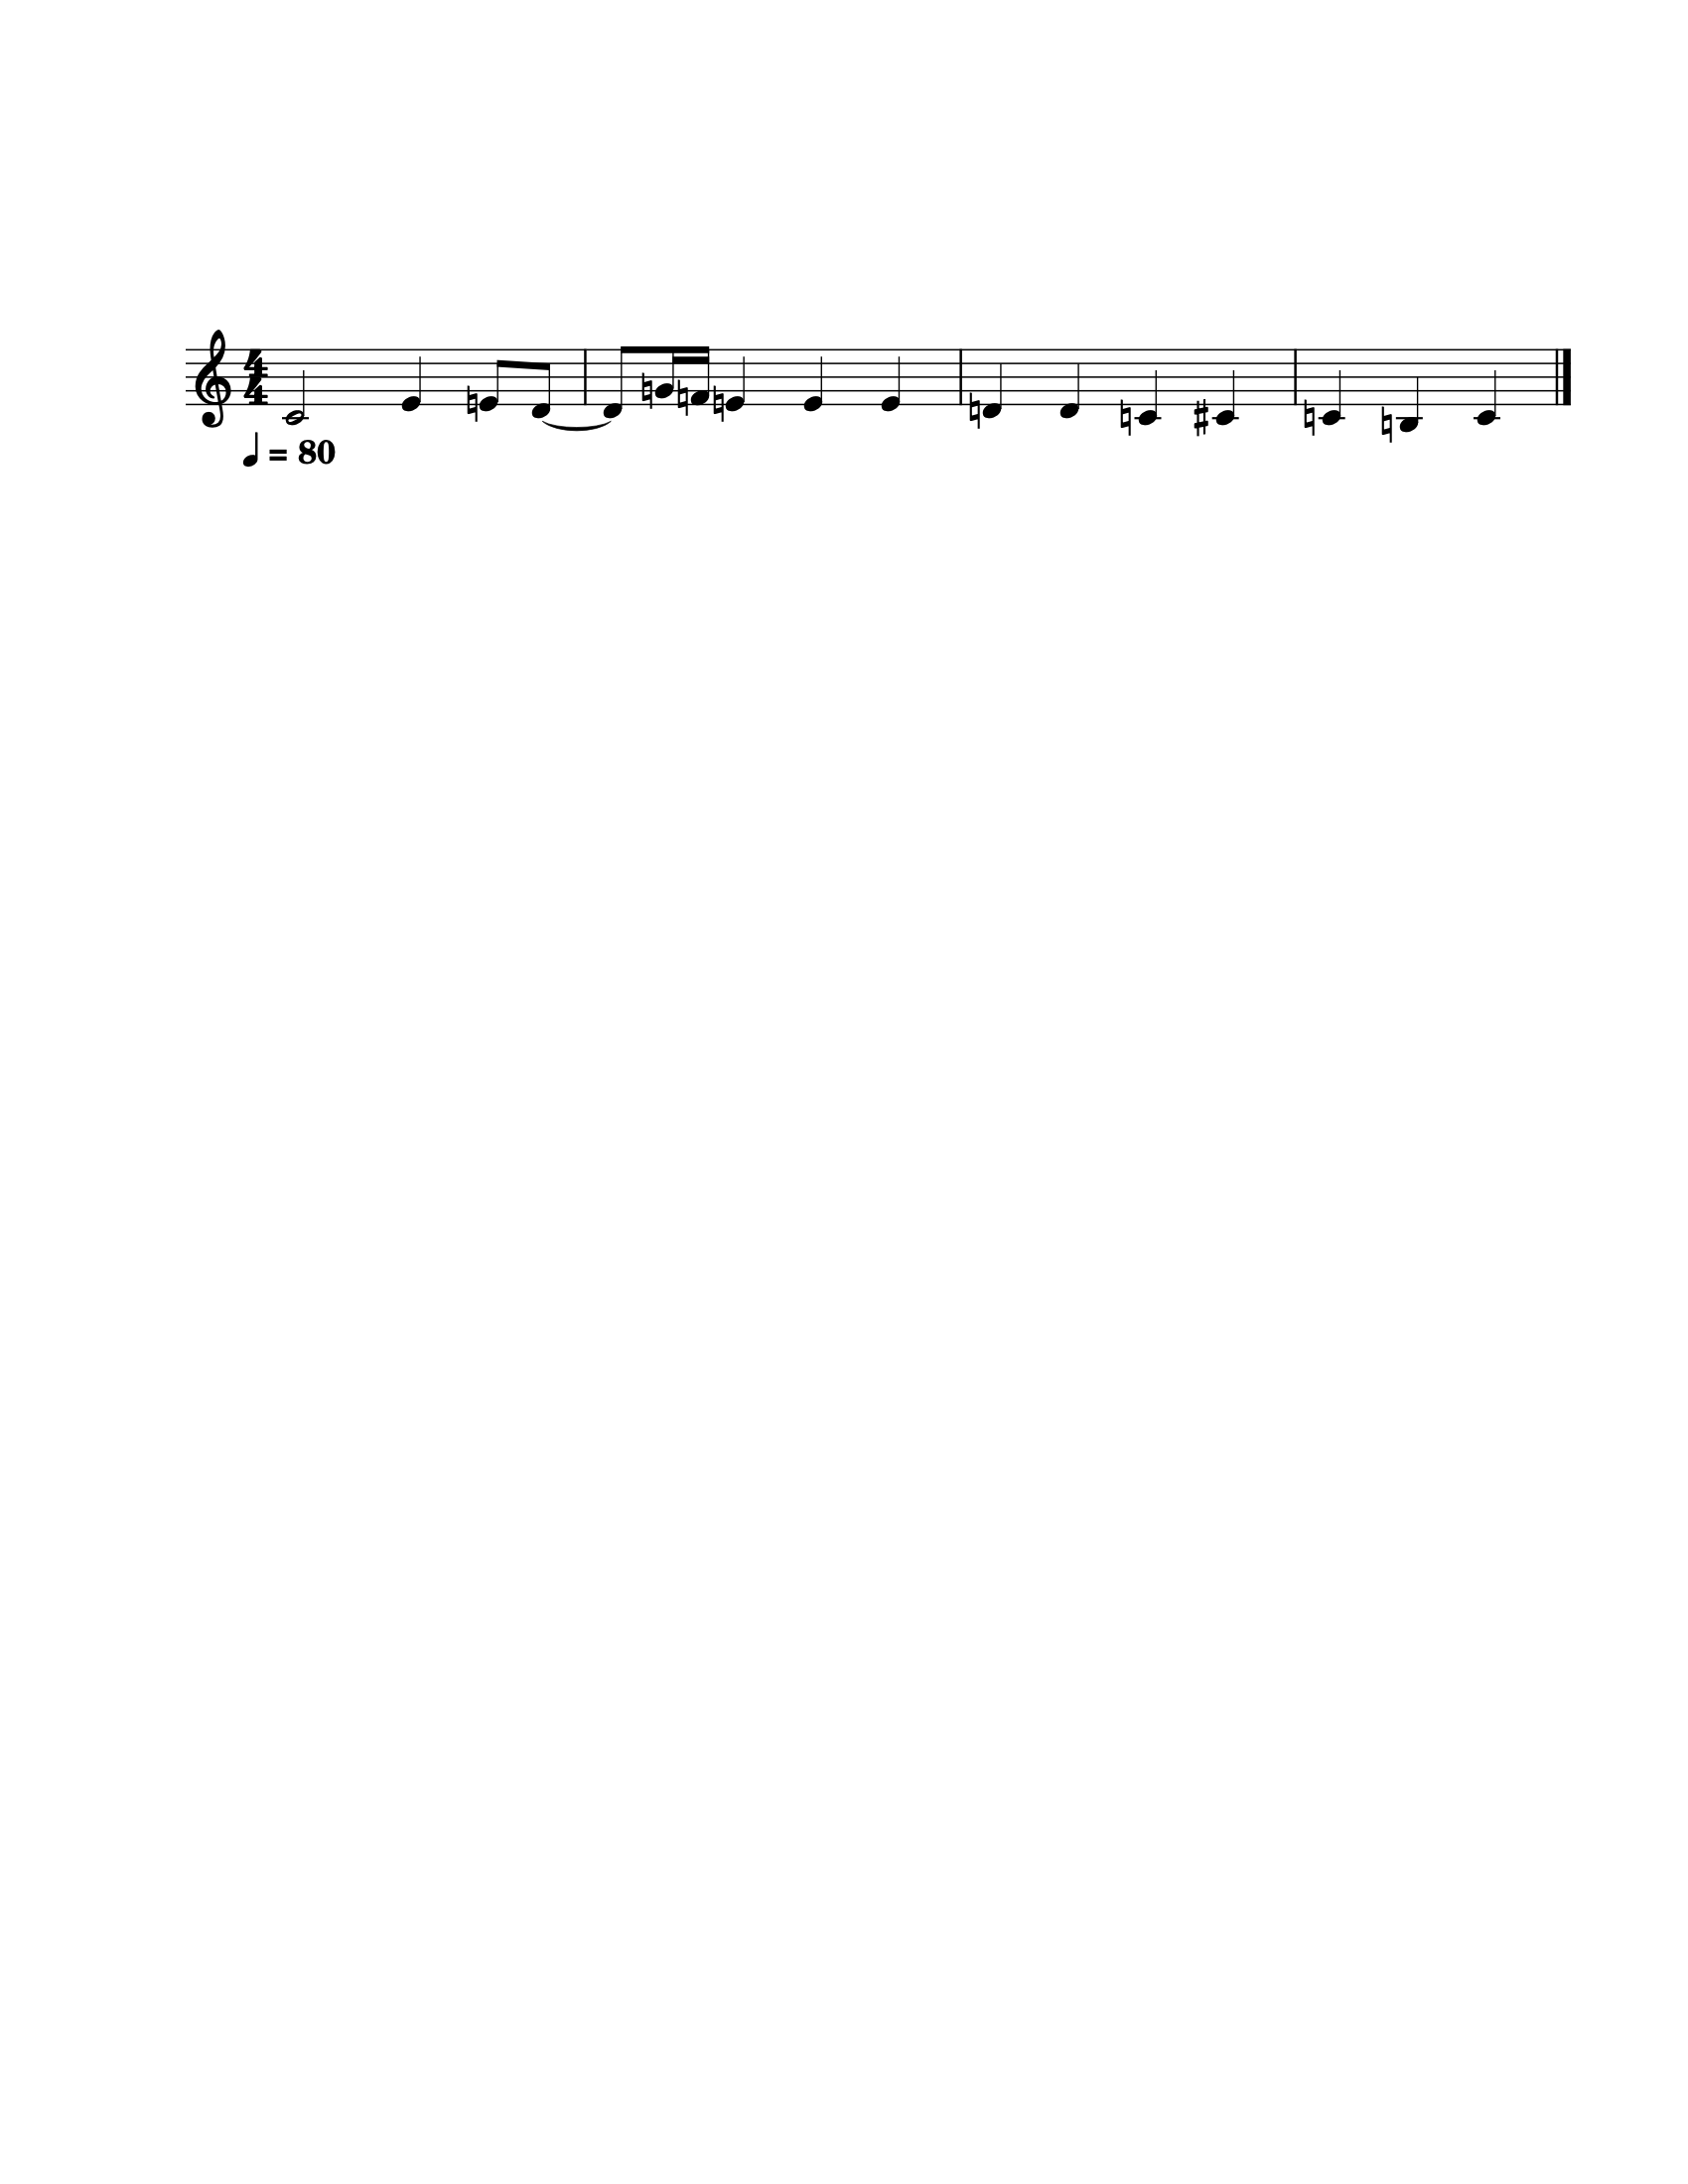

In [182]:
input_dir = '/Users/annie/Desktop/2023 Spring/MUSI 7100/week12/input_test/test02.mid'
note_dur_array = read_midi(input_dir)
pop_dir = '/Users/annie/Desktop/Chorales/Cmaj'
output_dir = '/Users/annie/Desktop/test02_output.mid'
best_individual = run_genetic(5, 0.4, 0.05, note_dur_array, pop_dir)
#print(best_individual)
write_midi(best_individual, output_dir)